# P21 — Pretraining, Scaling Laws & Data  *(feed it the whole internet)*

> **The story so far.** You built TinyGPT in `notebooks/00`–`13` and watched the assembled mind wake
> up and generate text. It's alive — but it has only ever read a few pages. A child raised on three
> sentences knows three sentences. So **Part 5 — raising a real mind** opens with the most dramatic
> meal of all: **we feed it the whole internet.** Trillions of words — books, code, the chaos of the
> open web — poured through the *exact same training loop you already know*. Nothing about the
> learning changes. The heartbeat is still *predict the next token → measure how wrong → step
> downhill*. It's just that heartbeat, run a billion-fold bigger.

This notebook demystifies **pretraining**: the enormous first phase where a mind learns language from
raw text using one objective — **predict the next token** — with no human labels at all. We'll make
concrete (1) the self-supervised objective, (2) the data and compute reality of feeding the internet,
and (3) **scaling laws** — the empirical rule that bigger model + more data predictably lowers the
loss, which is *why* the whole field races to scale.

## B1 — The pretraining objective is just next-token prediction (at scale)

Here's the quiet miracle that makes feeding the internet possible: the mind grades its *own*
homework. Hand it any sentence and hide the next word; its guess is the answer; the real next word is
the key. No human ever has to label anything. A foundation model (GPT, Llama, Mistral) is pretrained
on trillions of tokens with the loss you already know — cross-entropy on the next token (P03,
Notebook 00 B11). It's **self-supervised**: the label for each position is simply the next token in
the text, so *any* text is training data. That's the whole trick that unlocked web-scale training.

**Worked example.** For the text `"the cat sat"` tokenised as `[the, cat, sat]`, one sequence yields
*three* training signals (predict each token from those before it):
```
context "the"          -> target "cat"
context "the cat"      -> target "sat"
context "the cat sat"  -> target <end>
```
Loss = average −ln P(correct next token). We run a tiny real next-token training loop to show the
loss fall — pretraining is this, scaled up a billion-fold.

In [1]:
import torch, torch.nn as nn
torch.manual_seed(0)
# tiny char-level next-token model on one sentence -> watch it memorise (mini "pretraining")
text = "hello world "
chars = sorted(set(text)); stoi={c:i for i,c in enumerate(chars)}; V=len(chars)
data = torch.tensor([stoi[c] for c in text])
X = data[:-1]; Y = data[1:]                     # predict each char from the previous one

model = nn.Sequential(nn.Embedding(V, 16), nn.Linear(16, V))
opt = torch.optim.Adam(model.parameters(), lr=0.05)
for step in range(301):
    logits = model(X)
    loss = nn.functional.cross_entropy(logits, Y)
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 100 == 0: print(f"step {step:>3}  loss {loss.item():.3f}")
print("\nloss falls as the model learns which char follows which — next-token prediction, the pretraining objective.")

step   0  loss 2.102


step 100  loss 0.426


step 200  loss 0.426


step 300  loss 0.426

loss falls as the model learns which char follows which — next-token prediction, the pretraining objective.


## B2 — The data pipeline: where trillions of tokens come from

"Feed it the internet" sounds glamorous; the reality is closer to running a colossal water-treatment
plant. The web arrives filthy — duplicated, spammy, half boilerplate — and you cannot pour that
straight into the mind. The unglamorous bulk of pretraining is *cleaning the meal*:
1. **Collect** — web crawls (Common Crawl), books, code, Wikipedia.
2. **Clean** — remove boilerplate, dedupe (duplicates waste compute and hurt quality), filter spam/NSFW.
3. **Tokenize** — convert to token ids with a subword tokenizer (BPE — `notebooks/01`).
4. **Pack** — concatenate into fixed-length sequences for efficient batching.

**Scale check by hand.** A 1-billion-word corpus at ~1.3 tokens/word ≈ 1.3B tokens. Modern models
train on **trillions** — e.g. 2T tokens is ~1500× that. Data quality and dedup often matter *more*
than raw quantity.

In [2]:
# a peek at step 1-2 of the pipeline: dedup + simple cleaning shrink a corpus
docs = ["the cat sat", "the cat sat", "  THE  Dog  ran  ", "<html>buy now!!!</html>", "the dog ran"]
seen=set(); cleaned=[]
for d in docs:
    c = " ".join(d.lower().split())                       # normalise whitespace + case
    if c.startswith("<") or "buy now" in c: continue       # crude spam/boilerplate filter
    if c in seen: continue                                 # dedup
    seen.add(c); cleaned.append(c)
print("raw docs    :", len(docs))
print("after clean :", cleaned, f"({len(cleaned)} kept)")
print("real pipelines do this over billions of docs — dedup + quality filtering is most of the work.")

raw docs    : 5
after clean : ['the cat sat', 'the dog ran'] (2 kept)
real pipelines do this over billions of docs — dedup + quality filtering is most of the work.


## B3 — Scaling laws: bigger + more data → predictably lower loss

Now the strangest, most consequential fact in the whole story — the one that turned AI from a craft
into an industry. When you feed the mind more and grow it bigger, it doesn't improve *erratically*;
it improves on a **ruler-straight, predictable line**. Test loss falls as a **power law** in model
size `N`, dataset size `D`, and compute `C`. Roughly `loss ≈ a · N^(−α) + b`. Power laws are
straight lines on a log-log plot, so you can **extrapolate**: measure small models, predict the loss
of a model 100× larger *before* spending the money to train it.

**Worked example by hand** with `loss = 2·N^(−0.1)`:
```
N = 10⁶  : loss = 2·(10⁶)^(−0.1) = 2·10^(−0.6) = 2·0.251 = 0.50
N = 10⁸  : loss = 2·(10⁸)^(−0.1) = 2·10^(−0.8) = 2·0.158 = 0.32
N = 10¹⁰ : loss = 2·(10¹⁰)^(−0.1)= 2·10^(−1.0) = 2·0.100 = 0.20
```
Each 100× in size cuts the loss by a steady factor — diminishing but predictable returns.

N=1e+06: loss = 0.502
N=1e+08: loss = 0.317
N=1e+10: loss = 0.200


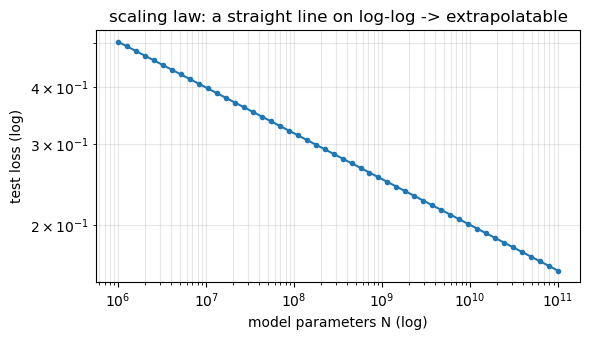

straight line on log-log = power law. This is how labs predict big-model loss from small runs.


In [3]:
import numpy as np, matplotlib.pyplot as plt
N = np.logspace(6, 11, 50)
loss = 2 * N**(-0.1)
for n in [1e6, 1e8, 1e10]:
    print(f"N={n:.0e}: loss = {2*n**-0.1:.3f}")
plt.figure(figsize=(6,3.5))
plt.loglog(N, loss, marker=".")
plt.xlabel("model parameters N (log)"); plt.ylabel("test loss (log)")
plt.title("scaling law: a straight line on log-log -> extrapolatable"); plt.grid(True, which="both", alpha=.3)
plt.tight_layout(); plt.show()
print("straight line on log-log = power law. This is how labs predict big-model loss from small runs.")

## B4 — Compute-optimal training (the "Chinchilla" lesson)

You have a fixed budget of GPU-hours to raise this mind. Spend it on a *bigger brain*, or on *more
reading*? It turns out you can't just max out one — a giant brain that's barely read is worse than a
modest brain that's read deeply. Given a fixed compute budget, should you make the model **bigger** or
train on **more data**? The
"Chinchilla" finding: most early large models were *under-trained* — for compute-optimal results,
parameters and training tokens should scale **together** (roughly ~20 tokens per parameter). A
smaller model trained on more data often beats a bigger model trained on less, for the same compute.
This reframed the field from "biggest model wins" to "best data/size balance wins."

In [ ]:
# === READ-ONLY — illustrative library code, not executed here ===
# How pretraining looks with HuggingFace (read-only — transformers is blocked here):
from transformers import GPT2LMHeadModel, GPT2Config, Trainer, TrainingArguments
config = GPT2Config(n_layer=12, n_head=12, n_embd=768, vocab_size=50257)  # ~124M params
model  = GPT2LMHeadModel(config)                                          # randomly initialised
# Trainer runs the exact next-token loop from B1, just at scale across many GPUs:
args = TrainingArguments(per_device_train_batch_size=8, max_steps=100_000, learning_rate=6e-4,
                         warmup_steps=2000, lr_scheduler_type="cosine")    # warmup+cosine = P12!
# trainer = Trainer(model=model, args=args, train_dataset=tokenized_corpus); trainer.train()

## Recap — pretraining

| Aspect | Reality |
|--------|---------|
| Objective | next-token cross-entropy, **self-supervised** (P03) |
| Data | trillions of tokens; cleaning & dedup dominate |
| Optimizer | AdamW + warmup + cosine decay (P12) |
| Scaling laws | loss ≈ power law in N, D, C → extrapolatable |
| Compute-optimal | scale params **and** tokens together (~20:1) |

## Common mistakes
1. **Confusing pretraining with fine-tuning.** Pretraining learns language from scratch on raw text; fine-tuning (P22+) adapts an already-pretrained model.
2. **Thinking more parameters always win.** Under-trained giant models lose to well-trained smaller ones (Chinchilla).
3. **Underrating data quality.** Dedup and filtering often beat raw token count.
4. **Forgetting it's the same loss you know.** Pretraining is just cross-entropy next-token prediction at scale.
5. **Expecting power laws to last forever.** They eventually bend (data/quality limits); extrapolate with caution.

## Exercises (do them in new code cells)
1. In B1, train on `"abcabcabc "`. Does the loss reach ~0? What pattern did it learn?
2. Using `loss = 2·N^(−0.1)`, predict the loss at `N = 10¹²` by hand, then in code.
3. How many training tokens would a 7-billion-parameter model want under the ~20:1 rule?
4. Add one more spam pattern to B2's filter and show it removes an extra doc.
5. Why does self-supervision (no labels) make web-scale pretraining possible, while supervised learning would not?

---

**The mind has now read the whole internet** — and it shows. It can complete almost any sentence,
because it has seen almost every sentence. But it's a brilliant, undisciplined autodidact: ask it a
question and it might continue with *another* question, because raw text is full of unanswered ones.
It knows everything and obeys nothing. Next, in
[P22 — Supervised Fine-Tuning & Instruction Tuning](P22_Supervised_FineTuning.ipynb), **we teach it
manners** — how to take a raw next-token predictor and turn it into a helpful assistant that actually
follows what you ask.